<a href="https://colab.research.google.com/github/Khyati-01-sahu/Customer-Churn-Analysis-Prediction/blob/main/Churn_Prediction_XGBoost_Binary_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
shantanudhakadd_bank_customer_churn_prediction_path = kagglehub.dataset_download('shantanudhakadd/bank-customer-churn-prediction')

print('Data source import complete.')


Using Colab cache for faster access to the 'bank-customer-churn-prediction' dataset.
Data source import complete.


# Introduction

Retention Rate is an indication of how good is our "product market fit" (PMF). If our PMF is not satisfactory, we should see our customers churning very soon. One of the powerful tools to improve Retention Rate (hence the PMF) is Churn Prediction.  
By using this technique, one can easily find out who is likely to churn in the given period. In this case study, we will use a bank customer dataset and go over the following steps to develop a Churn Prediction model:

* Exploratory data analysis
* Feature engineering
* Investigate and visualize how the features affect Retention by using Logistic Regression
* Building a classification model with XGBoost
* Predict the customer's churn probability

# Data preparation

In this section, we will import the data and try to understand its structure.  
Furthermore, we will visualize various features and analyze distribution of the data.

## Importing libraries

In [9]:
# For data wrangling
import numpy as np
import pandas as pd

# For visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
pd.options.display.max_rows = None #to show all rows
pd.options.display.max_columns = None #to show all columns

# For encoding categorical data
from sklearn.preprocessing import OneHotEncoder

# For scaling
from sklearn.preprocessing import MinMaxScaler

# For splitting data
from sklearn.model_selection import train_test_split

# For modelling
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import PolynomialFeatures

# For evaluation
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

## Plot style and size settings

We will set some aesthetic related deafults for better looking visualizations.  
Also, we will set some plot parameters default values for convenience.

In [10]:
# Aesthetics
sns.set_style('darkgrid')
sns.set_palette('Set2')
mpl_color = sns.color_palette('Set2')

# Plot features universal settings
plt.rc('axes', titlesize=18)
plt.rc('axes', labelsize=14)
plt.rc('xtick', labelsize=13)
plt.rc('ytick', labelsize=13)
plt.rc('legend', fontsize=13)
plt.rc('font', size=13)

## Importing data

We start with checking out how our data looks like and visualize how it interacts with our label Exited (churned - 1 or not - 0)

In [11]:
df = pd.read_csv(f'{shantanudhakadd_bank_customer_churn_prediction_path}/Churn_Modelling.csv', delimiter=',')
df1 = df.copy() # For further analysis
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


**The Data Frame 'df' has 10000 rows with 14 attributes.**
Out of all the features excluding rownumber, customerid and surname, we have:
* 5 Numerical features
* 5 Categorical features

In [13]:
df.nunique()

,0
RowNumber,10000
CustomerId,10000
Surname,2932
CreditScore,460
Geography,3
Gender,2
Age,70
Tenure,11
Balance,6382
NumOfProducts,4


# Data manipulation

Removing the first three columns - "RowNumber", "CustomerId" and "Surname", as they are unnecessary for this case study.

In [14]:
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis = 1)

In [15]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


* The data seems to be recorded at a certain instance of time and the importance of the same is unknown.
* There are entries where a customer has exited but still maintains some balance and has a credit card with the bank, which seems conflicting.

As we proceed with this case study, we will have to ignore these findings for the time being, although having a context regarding the attributes can help us in the decision-making process, and thus better modelling in the future.

# Exploratory data analysis

Here our main interest is to get an understanding as to how the given attributes relate to the 'Exited' status.

## Distribution of churned customers vs retained

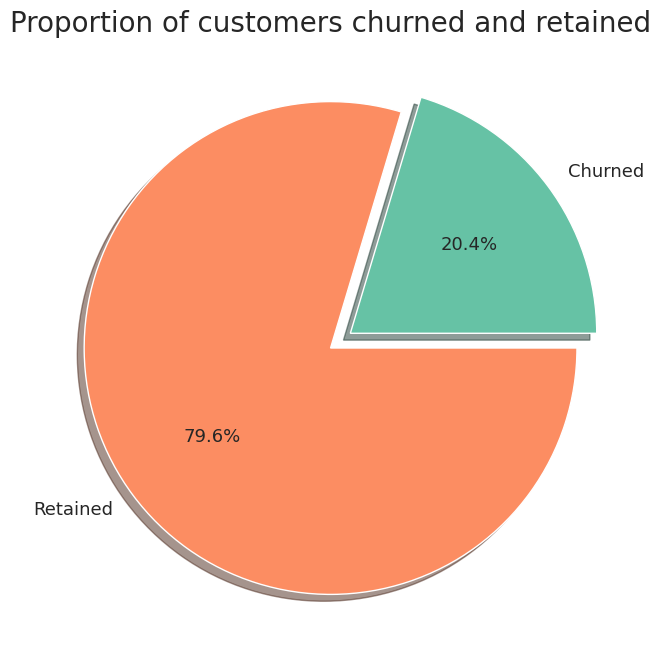

In [16]:
fig,ax = plt.subplots(figsize = (8, 8))
pie_data = [df.Exited[df["Exited"] == 1].count(), df.Exited[df["Exited"] == 0].count()]
pie_labels = ["Churned", "Retained"]
ax.pie(pie_data, labels = pie_labels, explode = [0.1, 0], shadow = True, colors = mpl_color, autopct = "%.1f%%")
plt.title("Proportion of customers churned and retained", size = 20)
plt.show()

So about 20% of the customers have churned.  
Given such a small percentage of churned customers, i.e unbalanced target classification, **our model performace should be evaluated based on a higher accuracy of "true positives"** so that the bank can focus on those customers in order to retain them.
We'll therefore use **ROC AUC scores** along with **F1 scores** instead of just accuracy scores. Most importantly, the **"Recall"** values will be the most significant part of our decision making in order to predict the maximum number of churned customers out of the total actually churned.

## Categorical features related to customer churn

Here, we shed light on all the categorical features and see how helpful they are to identify if a customer is going to churn.

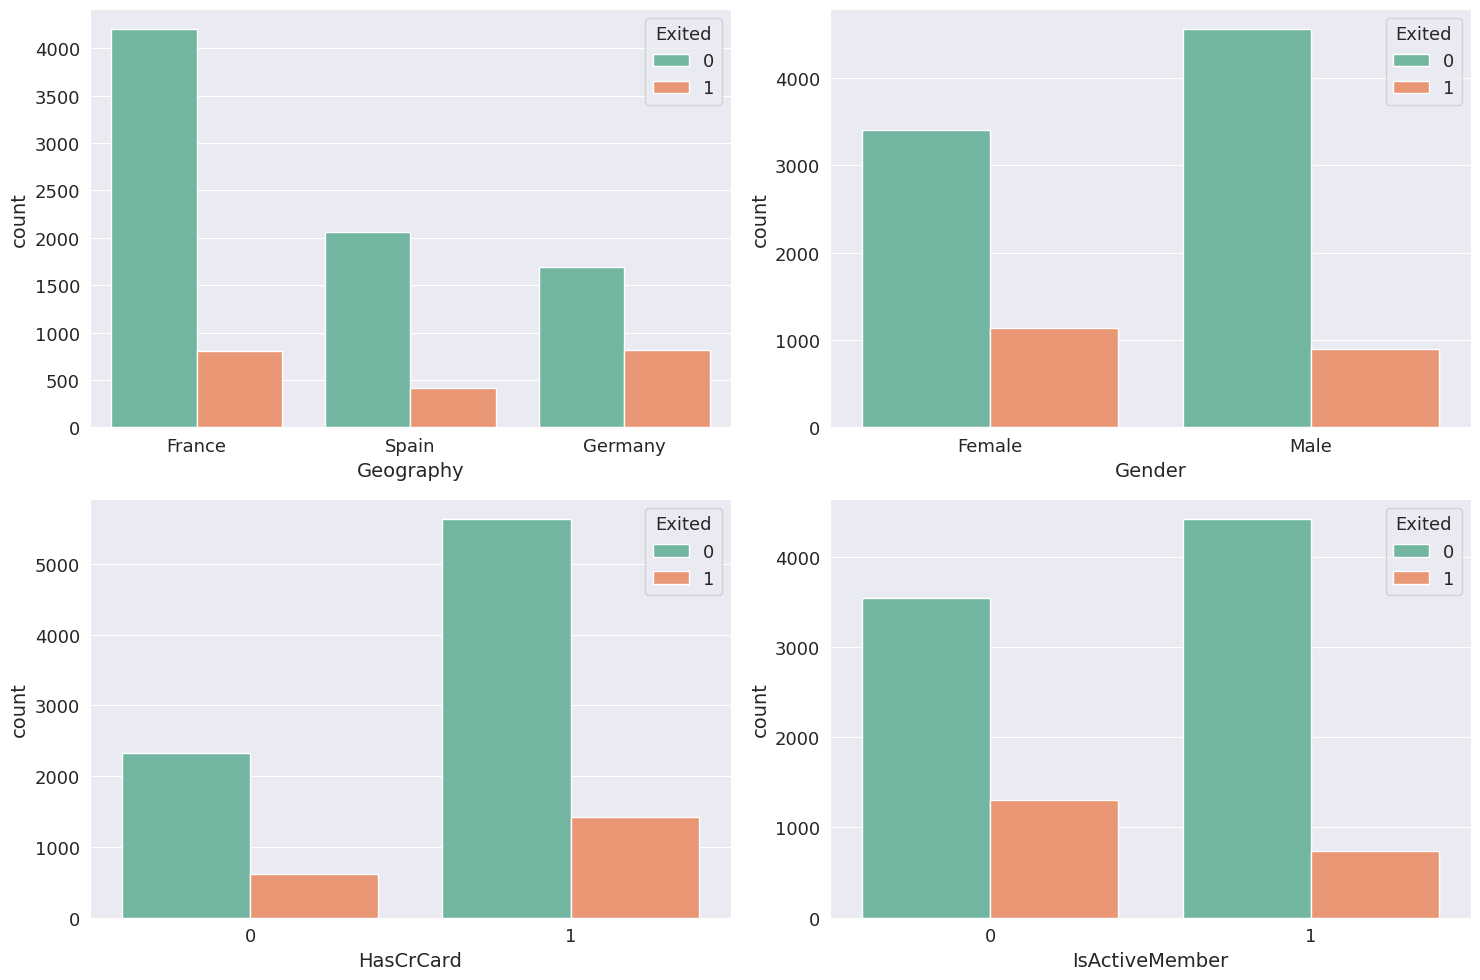

In [17]:
fig,ax = plt.subplots(2, 2, figsize = (15,10), tight_layout = True)
sns.countplot(data = df, x = "Geography", hue = "Exited", ax = ax[0,0])
sns.countplot(data = df, x = "Gender", hue = "Exited", ax = ax[0,1])
sns.countplot(data = df, x = "HasCrCard", hue = "Exited", ax = ax[1,0])
sns.countplot(data = df, x = "IsActiveMember", hue = "Exited", ax = ax[1,1])
plt.show()

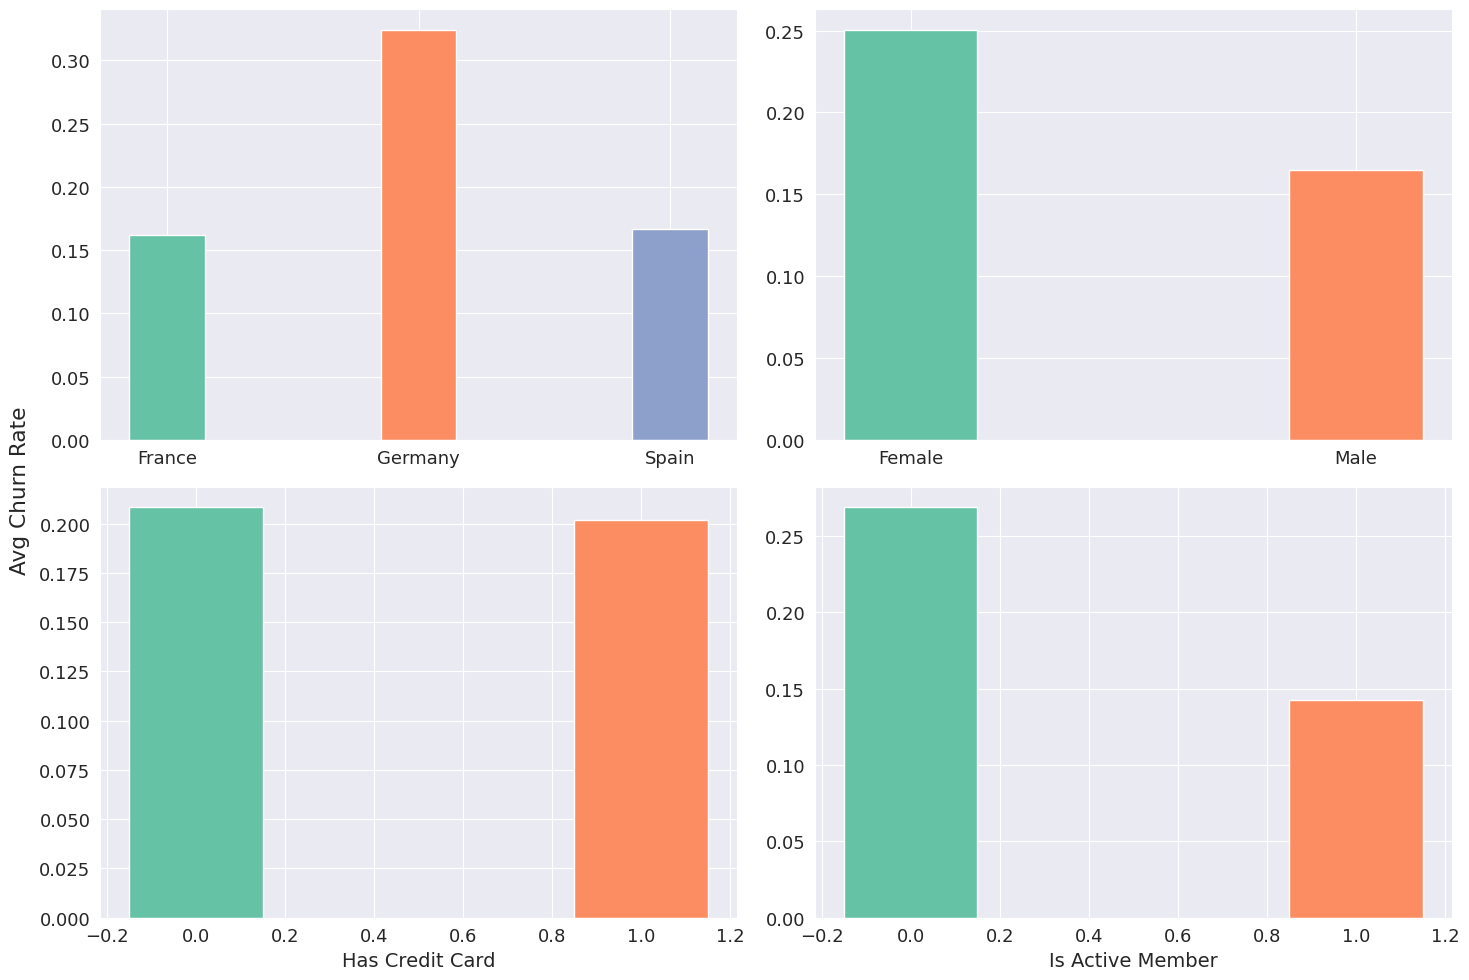

In [18]:
df_plot1 = df.groupby('Geography').Exited.mean().reset_index()
df_plot2 = df.groupby('Gender').Exited.mean().reset_index()
df_plot3 = df.groupby('HasCrCard').Exited.mean().reset_index()
df_plot4 = df.groupby('IsActiveMember').Exited.mean().reset_index()

fig, ax = plt.subplots(2,2, figsize = (15,10), tight_layout = True)
ax[0,0].bar(x = df_plot1["Geography"], height = df_plot1["Exited"], width = 0.3, color = mpl_color[0:3])
ax[0,1].bar(x = df_plot2["Gender"], height = df_plot2["Exited"], width = 0.3, color = mpl_color[0:2])
ax[1,0].bar(x = df_plot3["HasCrCard"], height = df_plot3["Exited"], width = 0.3, color = mpl_color[0:2])
ax[1,1].bar(x = df_plot4["IsActiveMember"], height = df_plot4["Exited"], width = 0.3, color = mpl_color[0:2])

fig.supylabel("Avg Churn Rate")
#plt.ylabel("Avg Churn Rate")
ax[1,0].set_xlabel("Has Credit Card")
ax[1,1].set_xlabel("Is Active Member")
plt.show()

Findings from the above plots 1 & 2 respectively for each subplot.

* **Geography**
    + The proportion of customers churned in a country is inversely proportional to the number of customers in that country.
    + Germany has the highest churn rate
* **Gender**
    + Although males contribute to a bigger proportion of customers, females seem to have a higher churning rate than males.
* **Has Credit Card**
    + Surprisingly, more customers owning a credit card seem to have exited the bank. Although the proportion of leavers in both the categories is almost the same.
    + And therefore from the second graph, both of them have the same churning rate.
* **Is Active Member**
    + More Inactive members have churned as compared to the active ones, which seems obvious here. Although, the amount of inactive members is almost the same as the active ones, which is not a good news for the bank.
    + Inactive members have almost the double churning rate.

## Numerical/Continuous features related to customer churn

<Axes: xlabel='Exited', ylabel='EstimatedSalary'>

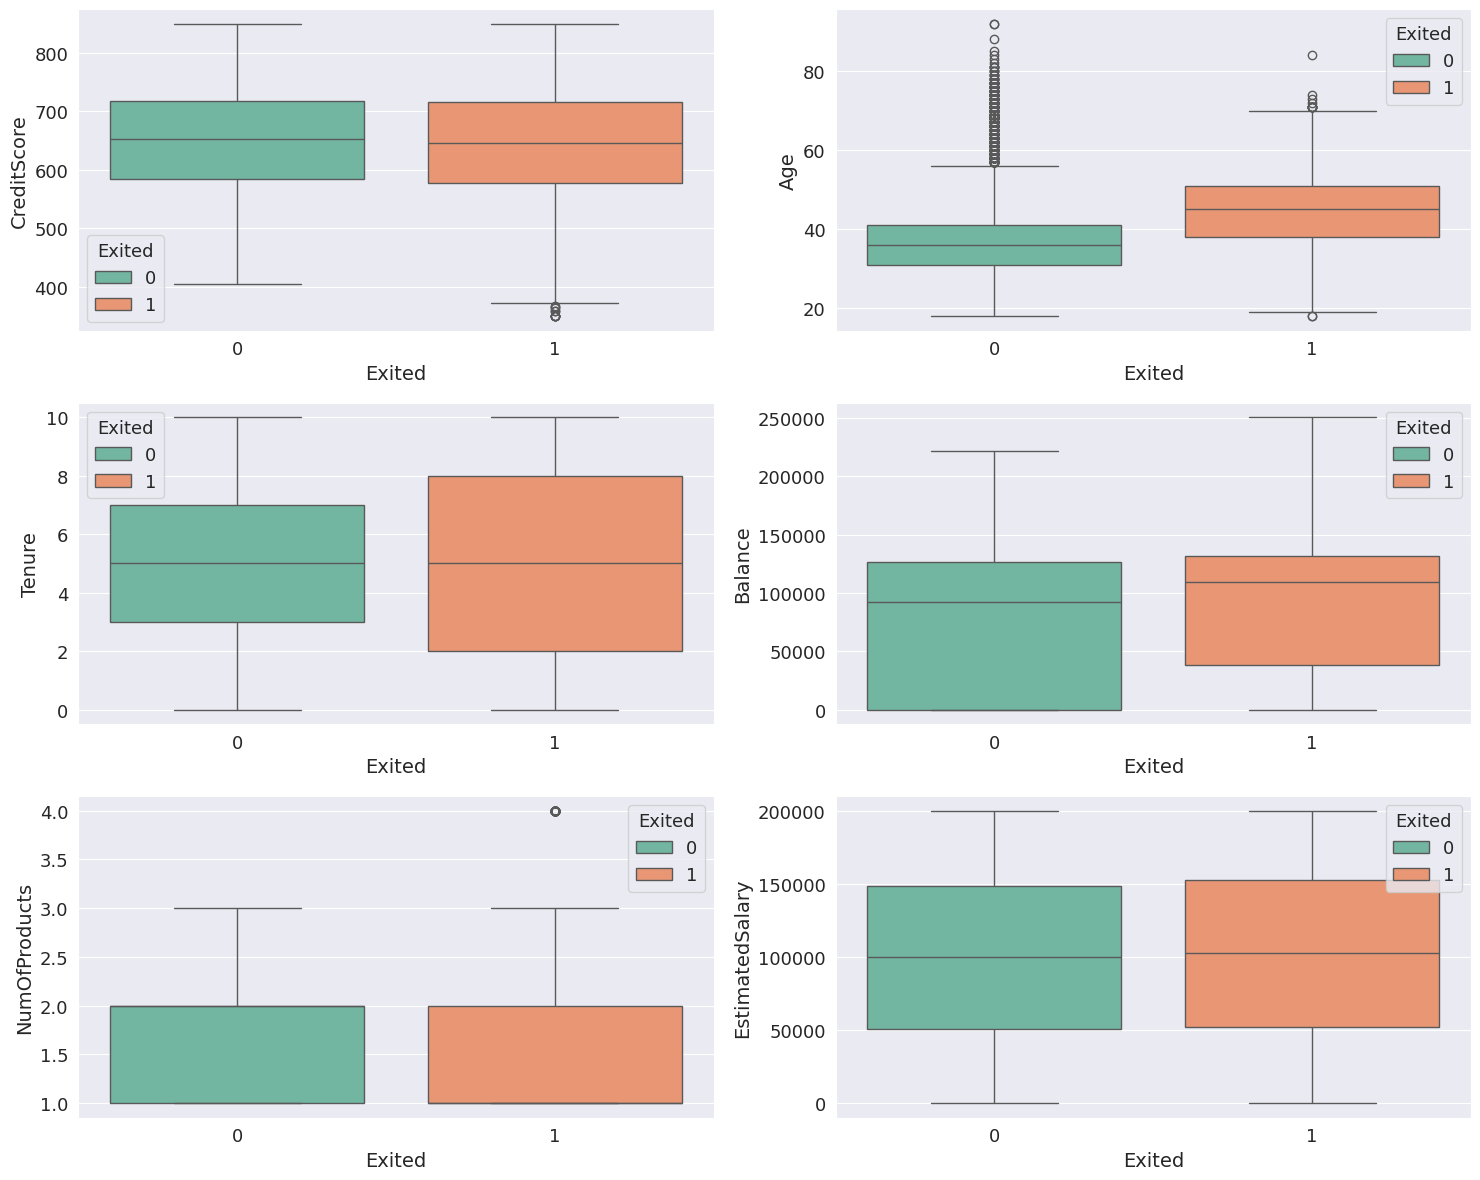

In [19]:
# Relations based on the continuous data attributes
fig, ax = plt.subplots(3, 2, figsize=(15, 12), tight_layout= True)
sns.boxplot(y='CreditScore',x = 'Exited', hue = 'Exited',data = df, ax=ax[0][0])
sns.boxplot(y='Age',x = 'Exited', hue = 'Exited',data = df , ax=ax[0][1])
sns.boxplot(y='Tenure',x = 'Exited', hue = 'Exited',data = df, ax=ax[1][0])
sns.boxplot(y='Balance',x = 'Exited', hue = 'Exited',data = df, ax=ax[1][1])
sns.boxplot(y='NumOfProducts',x = 'Exited', hue = 'Exited',data = df, ax=ax[2][0])
sns.boxplot(y='EstimatedSalary',x = 'Exited', hue = 'Exited',data = df, ax=ax[2][1])

Findings from above:

1. Credit score doesn't seem to have any impact on the churning rate, therefore an engineered feature with respect to age can be created to analyse further.
2. Older aged people have a tendency to churn more than the younger ones.
3. People with very low and very high tenure periods seem to show churn status, which is quite ambiguous, therefore a new feature with respect to age can be engineered.
4. Churned Customers had higher average balance. Balance with respect to the salary could be a better gauge to measure its influence on the churning rate.
5. Number of products and the estimated salary don't seem to have any effect on the churning rate.

/tmp/ipykernel_9245/4080870996.py:5: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[continuous_variables.index(item)].scatter(x = df_plot[item], y = df_plot.Exited, s = 15, c = mpl_color[continuous_variables.index(item)])
/tmp/ipykernel_9245/4080870996.py:5: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[continuous_variables.index(item)].scatter(x = df_plot[item], y = df_plot.Exited, s = 15, c = mpl_color[continuous_vari

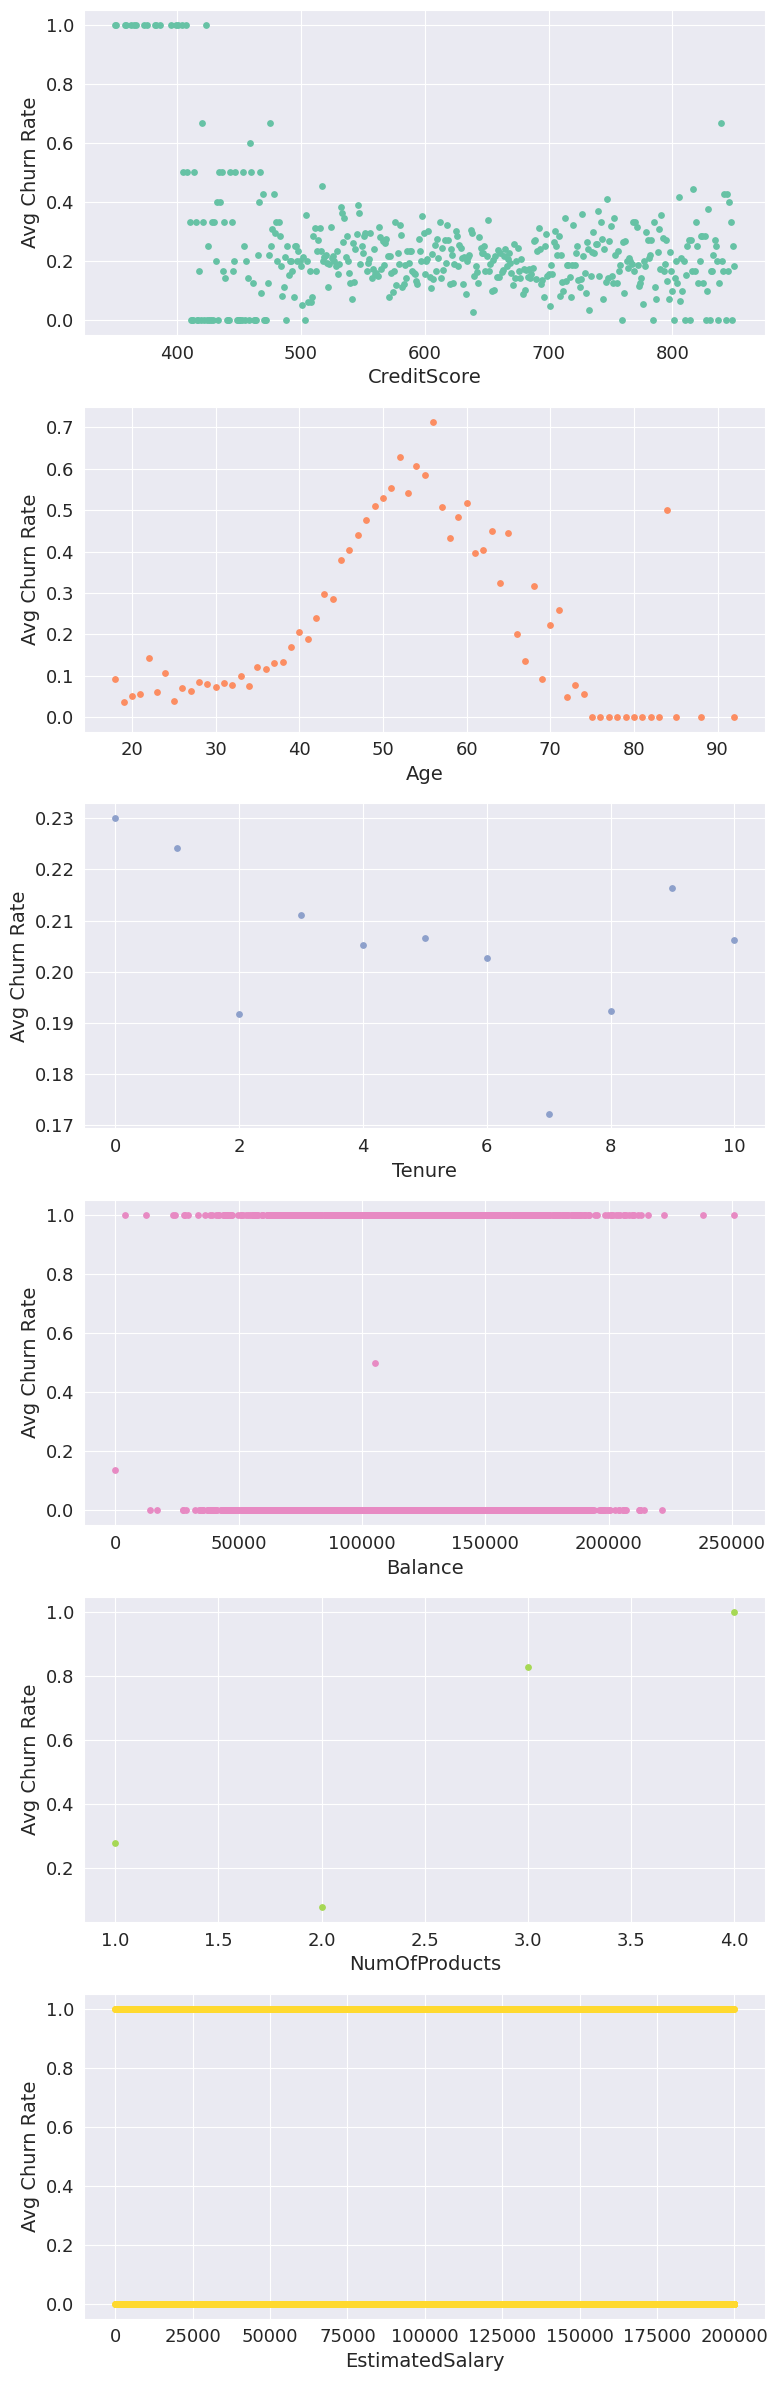

In [20]:
continuous_variables = ['CreditScore',  'Age', 'Tenure', 'Balance','NumOfProducts', 'EstimatedSalary']
fig, ax = plt.subplots(6, figsize = (8,24), tight_layout = True)
for item in continuous_variables:
    df_plot = df.groupby(item).Exited.mean().reset_index()
    ax[continuous_variables.index(item)].scatter(x = df_plot[item], y = df_plot.Exited, s = 15, c = mpl_color[continuous_variables.index(item)])
    ax[continuous_variables.index(item)].set_xlabel(item)
    ax[continuous_variables.index(item)].set_ylabel("Avg Churn Rate")
plt.show()

Contrary to the findings from the previous box plots, we have the following insights from scatter plots above:

* A very low credit score does seem to have a very high churn rate.
* A range of age between 50 to 60 also have a higher churn rate than other age groups.

# One hot encoding

The aim is to encode all the categorical features into 1s and 0s only.  
Geography column is therefore divided into its unique values and the same goes for the Gender column.

In [21]:
ohe1 = OneHotEncoder()
geo_transformed = ohe1.fit_transform(df[["Geography"]]).toarray()
geo_categories = ohe1.categories_[0]
df[geo_categories] = geo_transformed

In [22]:
ohe2 = OneHotEncoder()
gender_transformed = ohe2.fit_transform(df[["Gender"]]).toarray()
gender_categories = ohe2.categories_[0]
df[gender_categories] = gender_transformed

In [23]:
df = df.drop(["Geography", "Gender"], axis = 1)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,France,Germany,Spain,Female,Male
0,619,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0,1.0,0.0
1,608,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0,1.0,0.0
2,502,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0,1.0,0.0
3,699,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0,1.0,0.0
4,850,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0,1.0,0.0


# Checking correlation

In [24]:
df.corr()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,France,Germany,Spain,Female,Male
CreditScore,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094,-0.008928,0.005538,0.004780,0.002857,-0.002857
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323,-0.039208,0.046897,-0.001685,0.027544,-0.027544
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001,-0.002848,-0.000567,0.003868,-0.014733,0.014733
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533,-0.231329,0.401110,-0.134892,-0.012087,0.012087
NumOfProducts,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820,0.001230,-0.010419,0.009039,0.021859,-0.021859
HasCrCard,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138,0.002467,0.010577,-0.013480,-0.005766,0.005766
IsActiveMember,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128,0.003317,-0.020486,0.016732,-0.022544,0.022544
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097,-0.003332,0.010297,-0.006482,0.008112,-0.008112
Exited,-0.027094,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000,-0.104955,0.173488,-0.052667,0.106512,-0.106512
France,-0.008928,-0.039208,-0.002848,-0.231329,0.001230,0.002467,0.003317,-0.003332,-0.104955,1.000000,-0.580359,-0.575418,-0.006772,0.006772


<Axes: >

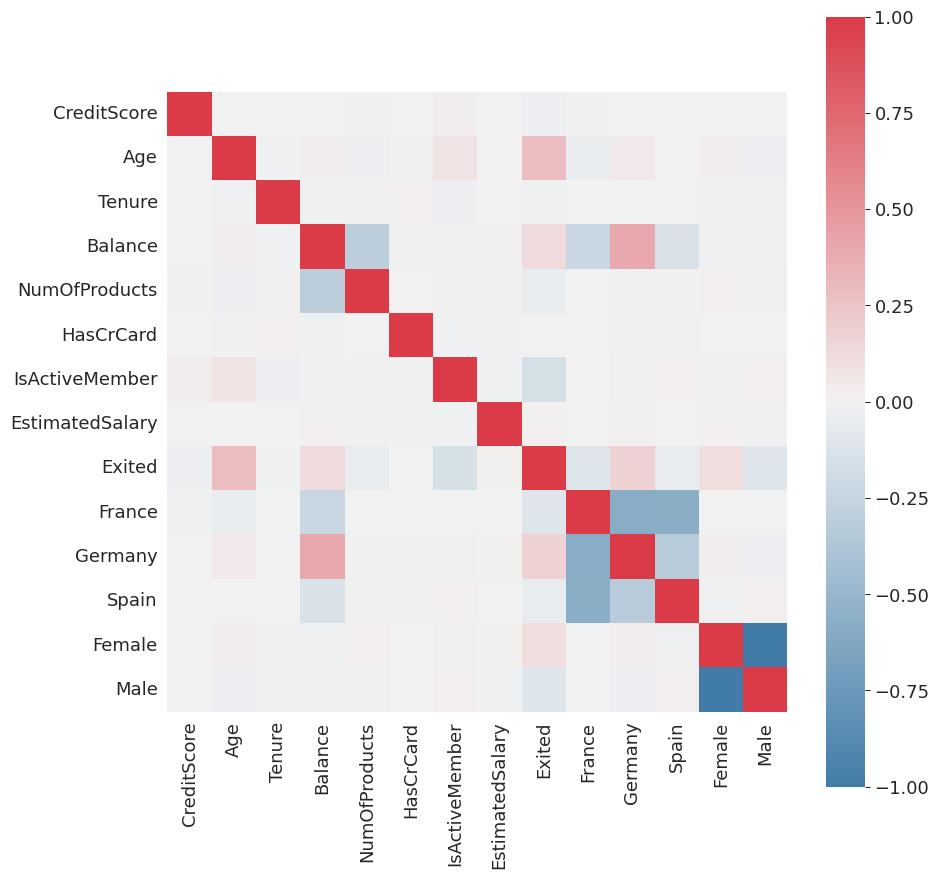

In [25]:
plt.figure(figsize=(10,10))
cmap = sns.diverging_palette(240, 10, as_cmap=True)
sns.heatmap(df.corr(), cmap = cmap, center=0, annot=False, square=True)

We can easily ignore the correlation ebtween Male - Female and France - Germany - Spain, as they these features were derived from the same parent feature.  
**"NumOfProducts" and "Germany" are slightly correlated to "Balance" with a coefficient of <-0.3 and >0.3 respectively.**

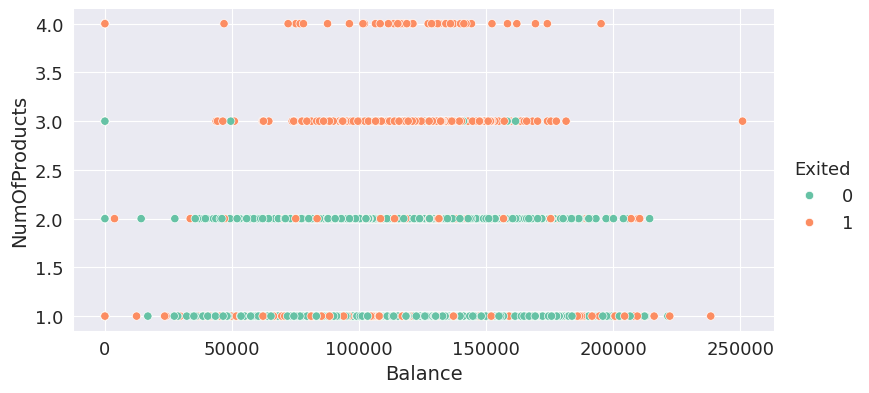

In [26]:
sns.pairplot(df, x_vars=["Balance"], y_vars=["NumOfProducts"], hue="Exited", height=4, aspect=2)


It seems like the Exit status is highly depended on the number of products owned by the customer. A higher number of products tends to have a higher churning possibility and vice versa.

# Feature engineering

We will make the following three features:
1. Balance vs salary ratio
2. Tenure vs age ratio
3. Credit Score vs age ratio

In [27]:
df['BalanceSalaryRatio'] = df.Balance/df.EstimatedSalary
df['TenureByAge'] = df.Tenure/df.Age
df['CreditScoreGivenAge'] = df.CreditScore/df.Age
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,France,Germany,Spain,Female,Male,BalanceSalaryRatio,TenureByAge,CreditScoreGivenAge
0,619,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0,1.0,0.0,0.000000,0.047619,14.738095
1,608,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0,1.0,0.0,0.744677,0.024390,14.829268
2,502,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0,1.0,0.0,1.401375,0.190476,11.952381
3,699,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0,1.0,0.0,0.000000,0.025641,17.923077
4,850,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0,1.0,0.0,1.587055,0.046512,19.767442


## Engineered features vs customer churn

(-1.0, 5.0)

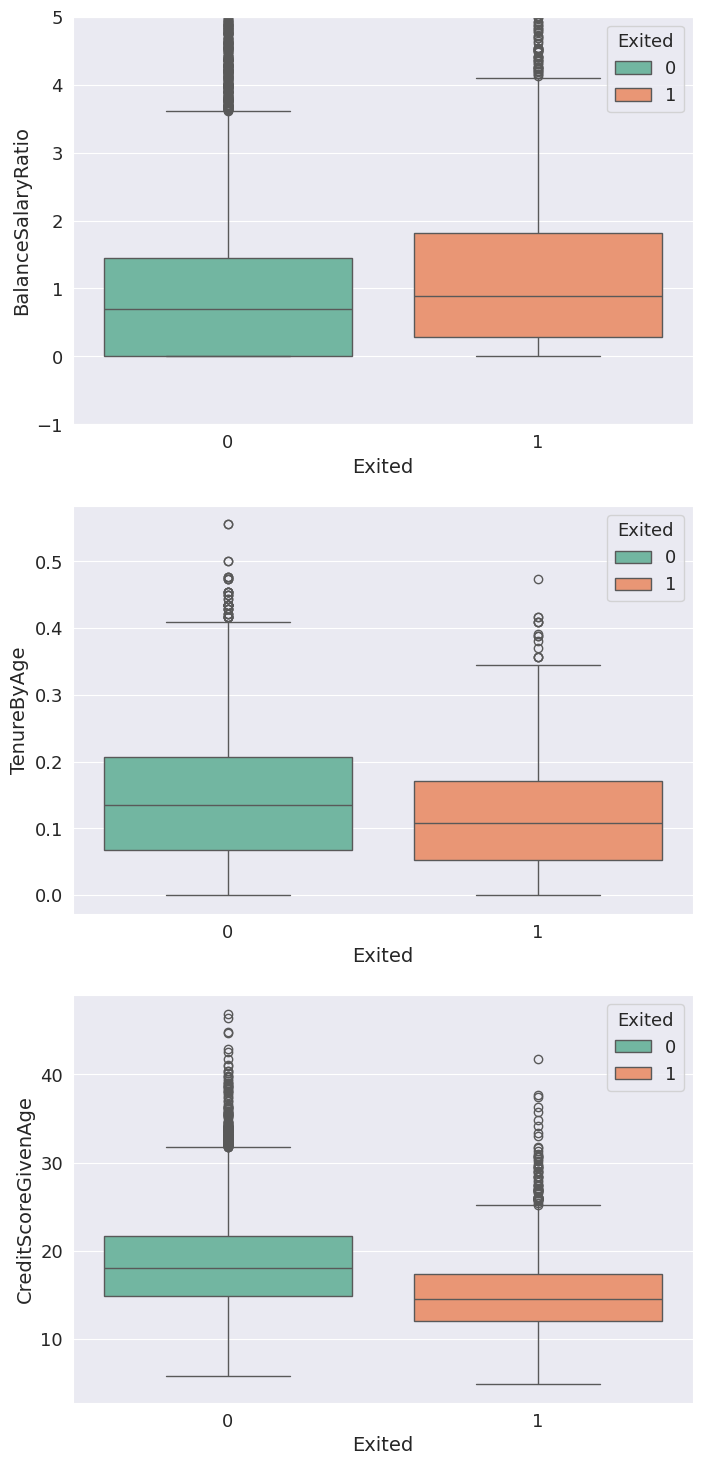

In [28]:
fig, ax = plt.subplots(3, figsize=(8,18))
sns.boxplot(y='BalanceSalaryRatio',x = 'Exited', hue = 'Exited',data = df, ax=ax[0])
sns.boxplot(y='TenureByAge',x = 'Exited', hue = 'Exited',data = df, ax=ax[1])
sns.boxplot(y='CreditScoreGivenAge',x = 'Exited', hue = 'Exited',data = df, ax=ax[2])
ax[0].set_ylim(-1,5)

1. High balance/salary --> Churn
2. Low credit-score/age --> Churn


# Min-Max scaling

Now, due to the varying ranges of the features, we will scale all the continuous variables using the min-max scaler.

In [29]:
to_scale = ['CreditScore',  'Age', 'Tenure', 'Balance','NumOfProducts', 'EstimatedSalary', 'BalanceSalaryRatio', 'TenureByAge', 'CreditScoreGivenAge']
scaler = MinMaxScaler()
df[to_scale] = scaler.fit_transform(df[to_scale])
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,France,Germany,Spain,Female,Male,BalanceSalaryRatio,TenureByAge,CreditScoreGivenAge
0,0.538,0.324324,0.2,0.000000,0.000000,1,1,0.506735,1,1.0,0.0,0.0,1.0,0.0,0.000000,0.085714,0.235083
1,0.516,0.310811,0.1,0.334031,0.000000,0,1,0.562709,0,0.0,0.0,1.0,1.0,0.0,0.000070,0.043902,0.237252
2,0.304,0.324324,0.8,0.636357,0.666667,1,0,0.569654,1,1.0,0.0,0.0,1.0,0.0,0.000132,0.342857,0.168807
3,0.698,0.283784,0.1,0.000000,0.333333,0,0,0.469120,0,1.0,0.0,0.0,1.0,0.0,0.000000,0.046154,0.310859
4,1.000,0.337838,0.2,0.500246,0.000000,1,1,0.395400,0,0.0,0.0,1.0,1.0,0.0,0.000150,0.083721,0.354739


# Train Test Split

Splitting the data into train set (80%) and test set (20%).

In [30]:
y = df.Exited
X = df.loc[:, df.columns != 'Exited']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Summary of feature importance coefficients

When we prepare a Churn Prediction model, we usually face these two questions below:
1. Which characteristics make customers churn or retain?
2. What are the most critical ones? What should we focus on?

We will try to answer these questions first before we get to the actual model building.

In [32]:
import statsmodels.api as sm
model = sm.Logit(y_train, X_train)
result = model.fit()

Optimization terminated successfully.
         Current function value: 0.426203
         Iterations 9


In [33]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:                 Exited   No. Observations:                 8000
Model:                          Logit   Df Residuals:                     7985
Method:                           MLE   Df Model:                           14
Date:                Sat, 18 Apr 2026   Pseudo R-squ.:                  0.1553
Time:                        18:03:17   Log-Likelihood:                -3409.6
converged:                       True   LL-Null:                       -4036.3
Covariance Type:            nonrobust   LLR p-value:                6.032e-259
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
CreditScore             2.0062      0.367      5.459      0.000       1.286       2.726
Age                     0.3671      0.637      0.576      0.564      -0.881       1.615
Tenure          

Features having absolute p-value less than 0.05 are considered significant:  
**CreditScore, Balance, IsActiveMember, CreditScoreGivenAge**  

In [34]:
np.exp(result.params)

,0
CreditScore,7.435107
Age,1.443507
Tenure,0.903887
Balance,1.712993
NumOfProducts,0.751693
HasCrCard,0.921495
IsActiveMember,0.355967
EstimatedSalary,1.047706
France,0.767425
Germany,1.659793


# Modelling

The following models will be tried in this case study:
1. Logistic regression classifier
2. Logistic regression (degree 2 polynomial) classifier
3. Random Forest classifier
4. Extreme Gradient Boosting classifier

## Hyperparameter tuning

### Logistic Regression - Hyperparameter tuning

In [35]:
param_grid = {'C': [0.5,1,10,100,500], 'max_iter' : [250, 300, 500], 'tol':[0.00001,0.0001,0.000001]}
lr_grid = GridSearchCV(LogisticRegression(),param_grid, cv=10)
lr_grid.fit(X_train, y_train)
print(lr_grid.best_score_)
print(lr_grid.best_params_)
print(lr_grid.best_estimator_)

0.8151250000000001
{'C': 100, 'max_iter': 250, 'tol': 1e-06}
LogisticRegression(C=100, max_iter=250, tol=1e-06)


### Logistic Regression with degree 2 polynomial - Hyperparameter tuning

In [36]:
X_train_poly = PolynomialFeatures(degree=2).fit_transform(X_train)
param_grid = {'C': [0.5,1,10,100], 'max_iter' : [300, 500], 'tol':[0.00001,0.0001]}
lr_poly_grid = GridSearchCV(LogisticRegression(solver = 'liblinear'),param_grid, cv=5)
lr_poly_grid.fit(X_train_poly, y_train)
print(lr_poly_grid.best_score_)
print(lr_poly_grid.best_params_)
print(lr_poly_grid.best_estimator_)

0.859125
{'C': 100, 'max_iter': 300, 'tol': 1e-05}
LogisticRegression(C=100, max_iter=300, solver='liblinear', tol=1e-05)


### Random Forest Classifier - Hyperparameter tuning

In [37]:
param_grid = {'max_depth': [5, 6, 7, 8], 'max_features': [4,6,7,8,9],'n_estimators':[50,100],'min_samples_split': [3, 5, 6, 7]}
rf_grid = GridSearchCV(RandomForestClassifier(),param_grid, cv=5)
rf_grid.fit(X_train, y_train)
print(rf_grid.best_score_)
print(rf_grid.best_params_)
print(rf_grid.best_estimator_)

0.863875
{'max_depth': 7, 'max_features': 9, 'min_samples_split': 6, 'n_estimators': 100}
RandomForestClassifier(max_depth=7, max_features=9, min_samples_split=6)


### XGB Classifier - Hyperparameter tuning

In [ ]:
param_grid = {'max_depth': [5,6,7,8], 'gamma': [0.01,0.001], 'learning_rate': [0.05,0.1, 0.2, 0.3], 'n_estimators':[5,10,20,100], 'min_child_weight':[1,5,10]}
xgb_grid = GridSearchCV(XGBClassifier(),param_grid, cv=5)
xgb_grid.fit(X_train, y_train)
print(xgb_grid.best_score_)
print(xgb_grid.best_params_)
print(xgb_grid.best_estimator_)

## Fitting best models

In [ ]:
lr_model = LogisticRegression(C=500, max_iter=250, tol=1e-05)
lr_model.fit(X_train, y_train)
lr_yhat = lr_model.predict(X_train)
print(classification_report(y_train, lr_yhat))

In [ ]:
X_train_poly = PolynomialFeatures(degree=2).fit_transform(X_train)
lr_poly_model = LogisticRegression(C=100, max_iter=300, solver='liblinear', tol=1e-05)
lr_poly_model.fit(X_train_poly, y_train)
lr_poly_yhat = lr_poly_model.predict(X_train_poly)
print(classification_report(y_train, lr_poly_yhat))

In [ ]:
rf_model = RandomForestClassifier(max_depth=8, max_features=9, min_samples_split=5, n_estimators = 100)
rf_model.fit(X_train, y_train)
rf_yhat = rf_model.predict(X_train)
print(classification_report(y_train, rf_yhat))

In [ ]:
xgb_model = XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, gamma=0.01, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.1, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=5, max_leaves=0, min_child_weight=1,
              monotone_constraints='()', n_estimators=100,
              n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1)
xgb_model.fit(X_train, y_train)
xgb_yhat = xgb_model.predict(X_train)
print(classification_report(y_train, xgb_yhat))

## ROC AUC scores and FPR - TPR calculations

In [ ]:
lr_score = roc_auc_score(y_train, lr_yhat)
lr_yhat_prob = lr_model.predict_proba(X_train)[:,1]
lr_fpr, lr_tpr, t1 = roc_curve(y_train, lr_yhat_prob)

lr_poly_score = roc_auc_score(y_train, lr_poly_yhat)
lr_poly_yhat_prob = lr_poly_model.predict_proba(X_train_poly)[:,1]
lr_poly_fpr, lr_poly_tpr, t2 = roc_curve(y_train, lr_poly_yhat_prob)

rf_score = roc_auc_score(y_train, rf_yhat)
rf_yhat_prob = rf_model.predict_proba(X_train)[:,1]
rf_fpr, rf_tpr, t3 = roc_curve(y_train, rf_yhat_prob)

xgb_score = roc_auc_score(y_train, xgb_yhat)
xgb_yhat_prob = xgb_model.predict_proba(X_train)[:,1]
xgb_fpr, xgb_tpr, t4 = roc_curve(y_train, xgb_yhat_prob)

In [ ]:
plt.figure(figsize = (12, 8), linewidth = 1)
plt.plot(lr_fpr, lr_tpr, label = "LR_score: " + str(round(lr_score, 3)))
plt.plot(lr_poly_fpr, lr_poly_tpr, label = "LR_poly_score: " + str(round(lr_poly_score, 3)))
plt.plot(rf_fpr, rf_tpr, label = "RF_score: " + str(round(rf_score, 3)))
plt.plot(xgb_fpr, xgb_tpr, label = "XGB_score: " + str(round(xgb_score, 3)))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend(loc='best')
plt.title(label = "ROC curve")
plt.show()

As discussed before, the focus of this model was based on the amount of correctly predicted 'churned' customers as well as the amount of actually churned customers that were predicted correctly, or in other words, precision and recall based on 1s.
This is in concern with the resources that the bank will have to use towards the strategy building, to target the customers who might churn based on the probability calculated by the model.  
As we can see from the plot above, XGB classifier has the highest score of all, with a precision score on 1's of 0.87, out of all customers that the model thinks will churn, 87% do actually churn and with the recall score of 0.56 on the 1's, the model is able to highlight 56% of all those who actually churned.

# Test predictions

Using the above fitted XGB model, we will find out how it performs on the test data.

In [ ]:
xgb_yhat_test = xgb_model.predict(X_test)
print(classification_report(y_test, xgb_yhat_test))
xgb_score_test = roc_auc_score(y_test, xgb_yhat_test)
xgb_yhat_test_prob = xgb_model.predict_proba(X_test)[:,1]
xgb_fpr_test, xgb_tpr_test, t5 = roc_curve(y_test, xgb_yhat_test_prob)

In [ ]:
plt.figure(figsize = (12, 8), linewidth = 1)
plt.plot(xgb_fpr_test, xgb_tpr_test, label = "XGB_score: " + str(round(xgb_score_test, 3)), color = mpl_color[3])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend(loc='best')
plt.title(label = "ROC curve - XGB Model")
plt.show()

# Feature importance

In [ ]:
def plot_feature_importance(importance,names,model_type):
    feature_importance = np.array(importance)
    feature_names = np.array(names)

    data={'feature_names':feature_names,'feature_importance':feature_importance}
    fi_df = pd.DataFrame(data)

    fi_df.sort_values(by=['feature_importance'], ascending=False,inplace=True)

    plt.figure(figsize=(10,8))
    sns.barplot(x=fi_df['feature_importance'], y=fi_df['feature_names'])
    plt.title(model_type + ' FEATURE IMPORTANCE')
    plt.xlabel('FEATURE IMPORTANCE')
    plt.ylabel('FEATURE NAMES')

plot_feature_importance(xgb_model.feature_importances_,X_test.columns,'Extreme Gradient Boosting')

# Conclusion

Testing resulted in the accuracy of 0.87 and slightly reduced AUC score (0.726), with an F1 score of 0.92 on retained customers and 0.60 on churned customers.  
Out of all the actual churned customers, the model has predicted 49% correctly.
Out of all the predicted churned customers, 76% actually churned.  
These numbers can be improved by implementing the model with more data over time and also by introducing better features provided that context for the features is known for better feature engineering.  
  
Finally, the best way to use this model is assigning Churn Probability for each customer, create segments, and build strategies on top of that.

In [ ]:
df1['Churn_prob'] = xgb_model.predict_proba(df[X_train.columns])[:,1]
df1[["CustomerId", "Churn_prob"]].head()